<a href="https://colab.research.google.com/github/fralfaro/MAT306/blob/main/docs/lectures/machine_learning/ts_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Series Temporales I

## Introducción

<div align="center">
<img src="https://www.scylladb.com/wp-content/uploads/time-series-data-diagram.png" width="800"/>
</div>




Una [serie temporal](https://en.wikipedia.org/wiki/Time_series) es una sucesión de datos ordenados cronológicamente, con intervalos regulares o irregulares entre observaciones. Su análisis es fundamental para tareas de **predicción y pronóstico**, con aplicaciones en campos como la estadística, econometría, procesamiento de señales, meteorología y finanzas.




## Análisis de Series Temporales

Para comprender el comportamiento de una serie temporal, utilizaremos **Python** como herramienta principal.

### Descripción del Problema

El conjunto de datos `AirPassengers.csv` contiene el número mensual de pasajeros aéreos entre **1949 y 1960**.
En términos estadísticos, se representa como una serie temporal
[
{X_t : t \in T}
]
donde:

* (X_t): número total de pasajeros en el mes (t)
* (t): tiempo medido mensualmente

Esta serie equivale a un *dataframe* de una sola columna, cuyo índice corresponde a las fechas.

El objetivo es **predecir el número de pasajeros para los próximos dos años**. Antes de ajustar un modelo, se debe analizar el comportamiento de la serie y determinar cuál modelo se adapta mejor (si existe uno adecuado).

Para ello, usaremos la librería **statsmodels** de Python, ideal para el análisis de series de tiempo.
El primer paso consiste en **cargar, transformar y visualizar los datos** para explorar sus patrones.



In [25]:
# librerias 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm


# graficos incrustados
sns.set_style("whitegrid")
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [26]:
# Cargar dataset flights
df = sns.load_dataset("flights")

# Transformar el mes a número
df["month_num"] = pd.to_datetime(df["month"], format="%b").dt.month

# Crear columna datetime combinando año y mes
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month_num"].astype(str) + "-01")

# Renombrar columnas (por claridad, opcional)
df = df.rename(columns={"passengers": "passengers"}).drop(columns=["month", "month_num", "year"],axis=1)
df.head()

,passengers,date
0,112,1949-01-01
1,118,1949-02-01
2,132,1949-03-01
3,129,1949-04-01
4,121,1949-05-01


In [27]:
# resumen
df.describe()

,passengers,date
count,144.000000,144
mean,280.298611,1954-12-16 05:00:00
min,104.000000,1949-01-01 00:00:00
25%,180.000000,1951-12-24 06:00:00
50%,265.500000,1954-12-16 12:00:00
75%,360.500000,1957-12-08 18:00:00
max,622.000000,1960-12-01 00:00:00
std,119.966317,NaN


In [28]:
# fechas
print('Fecha Inicio: {}\nFecha Fin:    {}'.format(df.date.min(),df.date.max()))

Fecha Inicio: 1949-01-01 00:00:00
Fecha Fin:    1960-12-01 00:00:00


In [29]:
# formato datetime de las fechas
df['date'] = pd.to_datetime(df['date'], format='%Y-%m')

# dejar en formato ts
y = df.set_index('date').resample('ME').mean()

y.head()

,passengers
date,
1949-01-31,112.0
1949-02-28,118.0
1949-03-31,132.0
1949-04-30,129.0
1949-05-31,121.0


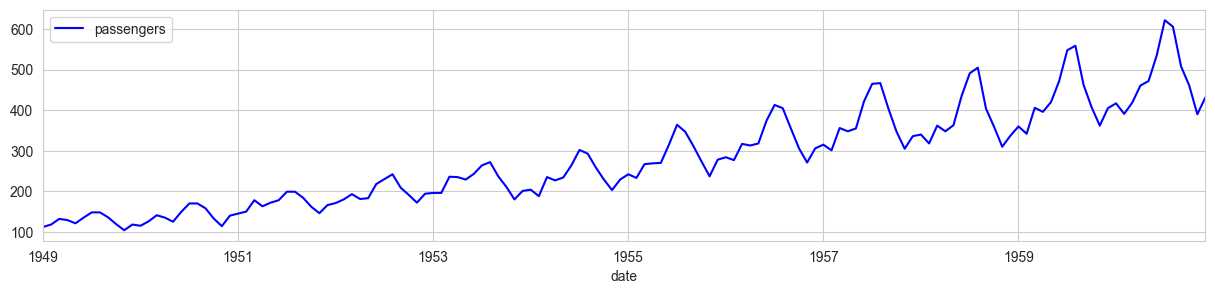

In [30]:
# graficar datos
y.plot(figsize=(15, 3),color = 'blue')
plt.show()

Se observa una **tendencia creciente** a lo largo del tiempo (cada año viajan más personas) y una **patrón estacional** marcado: los picos se repiten aproximadamente cada año, lo que indica **mayor demanda en ciertos meses** (como temporada alta).

Por otro lado, podemos **profundizar en la comprensión de la serie temporal** mediante un **diagrama de cajas (boxplot)** que muestre la distribución de los datos a lo largo de los distintos años.

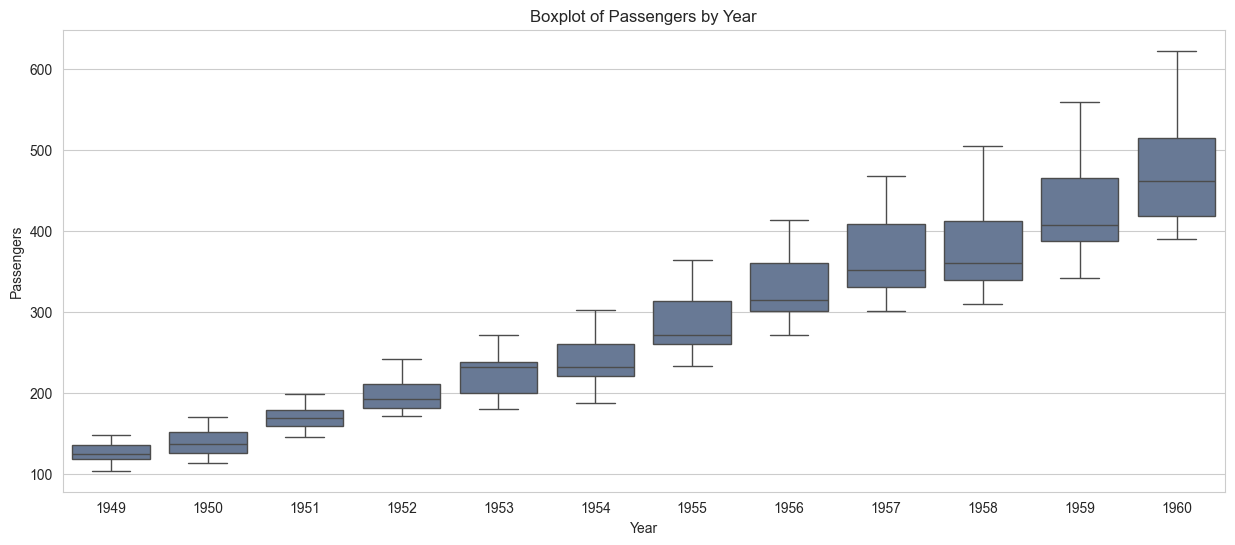

In [31]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(x=y.index.year, y=y["passengers"], data=y, ax=ax)

# Set labels and title
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.title("Boxplot of Passengers by Year")

# Display the plot
plt.show()



### Descomposición STL

Una **serie temporal** puede descomponerse en tres componentes principales:

* **Tendencia** ($T$): dirección general de los datos a lo largo del tiempo (creciente o decreciente).
* **Estacionalidad** ($S$): fluctuaciones regulares y predecibles que se repiten en intervalos definidos (por ejemplo, cada año o cada semestre).
* **Ruido** ($e$): variaciones aleatorias o errores asociados a la medición o a factores no observados.

Cuando se separa la serie temporal en estas tres partes —**tendencia**, **estacionalidad** y **ruido**— se denomina **descomposición STL** (*Seasonal-Trend decomposition using Loess*).
En algunos casos, esta descomposición no es completamente posible si la serie no presenta un comportamiento cíclico o repetitivo en el período analizado.

Existen dos enfoques principales para realizar la descomposición:

* **Aditiva:**
  $$X_{t} = T_{t} + S_{t} + e_{t}$$

* **Multiplicativa:**
  $$X_{t} = T_{t} \times S_{t} \times e_{t}$$

Aunque no es la única forma de analizar una serie temporal, esta técnica ofrece un punto de partida sólido para comprender su estructura.

En este caso, realizaremos una **descomposición multiplicativa** utilizando la función `seasonal_decompose` de la librería **statsmodels**.



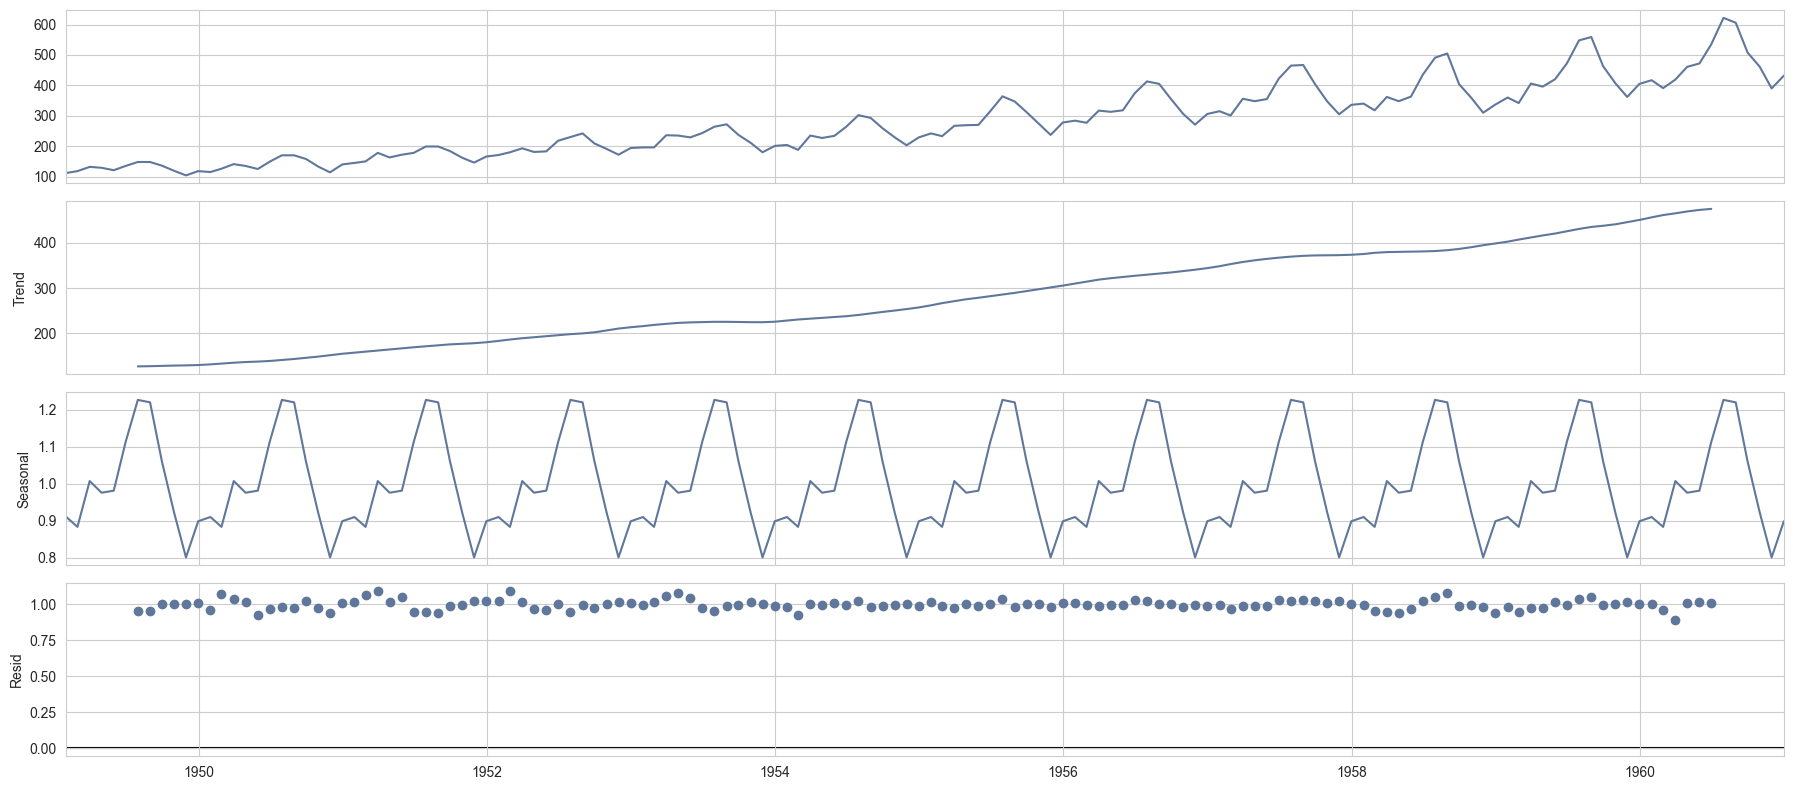

In [32]:
from pylab import rcParams
import statsmodels.api as sm
import matplotlib.pyplot as plt

rcParams['figure.figsize'] = 18, 8
decomposition = sm.tsa.seasonal_decompose(y, model='multiplicative')
fig = decomposition.plot()
plt.show()

El gráfico muestra la **descomposición STL** de la serie temporal de pasajeros aéreos.
Cada panel representa uno de los componentes principales:

1. **Serie original (arriba):**
   Muestra el número mensual de pasajeros entre 1949 y 1960. Se observa una clara **tendencia creciente** y un **patrón estacional repetitivo** cada año.

2. **Tendencia (Trend):**
   Representa el crecimiento sostenido en el número de pasajeros a lo largo del tiempo. La línea ascendente indica un **aumento constante** en la demanda de vuelos.

3. **Estacionalidad (Seasonal):**
   Muestra las **fluctuaciones cíclicas anuales**: cada año hay picos y valles que se repiten, reflejando la **temporada alta y baja** del transporte aéreo.

4. **Residuo (Resid):**
   Corresponde al **ruido o variabilidad no explicada** por la tendencia ni la estacionalidad. Se distribuye en torno a 1 (por ser una descomposición multiplicativa) y no muestra un patrón sistemático, lo que indica un **buen ajuste del modelo**.





Finalmente, para evaluar si el **residuo** obtenido se comporta como un **ruido blanco**, veamos cómo luce uno generado artificialmente en Python.

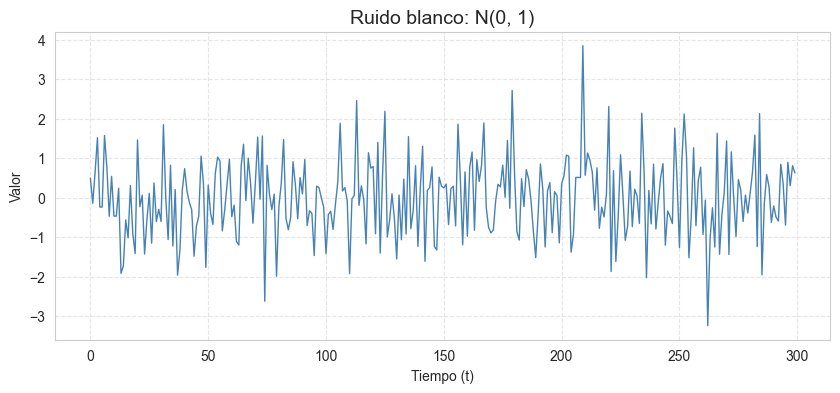

In [33]:
# Gráfico: Ruido blanco con distribución normal N(0,1)

import numpy as np
import matplotlib.pyplot as plt

# Fijar semilla para reproducibilidad
np.random.seed(42)

# Parámetros del ruido blanco
mean = 0       # media
std = 1        # desviación estándar
num_samples = 300  # número de observaciones

# Generar muestras aleatorias ~ N(0,1)
samples = np.random.normal(mean, std, size=num_samples)

# Visualizar la serie
plt.figure(figsize=(10, 4))
plt.plot(samples, color='steelblue', linewidth=1)
plt.title("Ruido blanco: N(0, 1)", fontsize=14)
plt.xlabel("Tiempo (t)")
plt.ylabel("Valor")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

El gráfico muestra un **ruido blanco**, es decir, una serie de valores **aleatorios sin patrón**.
Los puntos **suben y bajan sin tendencia ni repetición**, oscilando alrededor de **cero**.



Veamos cómo se distribuyen sus valores a través de un histograma.

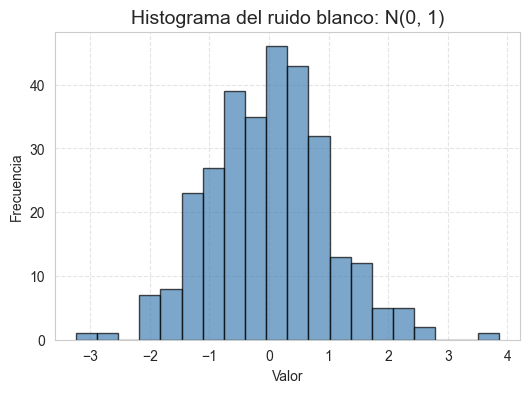

In [34]:
# Gráfico: Histograma del ruido blanco

plt.figure(figsize=(6, 4))
plt.hist(samples, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.title("Histograma del ruido blanco: N(0, 1)", fontsize=14)
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

El gráfico muestra cómo se distribuyen los valores del **ruido blanco**.
La mayoría se concentra cerca de **0**, y pocos se alejan hacia los extremos, formando una **curva en forma de campana**, típica de una **distribución normal**.


### Series Estacionarias

Un concepto fundamental en el análisis de series temporales es el de **estacionariedad**.

#### Definición

Sea $\{ X_t : t \in T \}$ una serie temporal.
Se dice que la serie es **débilmente estacionaria** si cumple las siguientes condiciones:

* $\mathbb{V}(X_t) < \infty$, para todo $t \in T$.
* $\mu_X(t) = \mu$, es decir, su media es constante en el tiempo.
* $\gamma_X(r, s) = \gamma_X(r + h, s + h) = \gamma_X(h)$, para todo $r, s, h \in T$, lo que significa que la covarianza depende solo de la distancia entre los puntos, y no del tiempo en que se mida.

En palabras simples, una serie temporal es **débilmente estacionaria** cuando **sus valores fluctúan alrededor de una media constante** y **su variabilidad no cambia a lo largo del tiempo**.

Veamos algunos ejemplos visuales:



<img src="https://miro.medium.com/v2/1*xdblkZyg6YmmReAkZHUksw.png" width = "900" align="center"/>



La imagen muestra los **principios de estacionariedad** en una serie temporal.

* **Imagen A (verde)**: representa una **serie estacionaria**, donde la media, la varianza y la covarianza se mantienen constantes en el tiempo. Los valores oscilan alrededor de una media fija con una variabilidad estable.

* **Imagen B (roja)**: la **media cambia con el tiempo** (tendencia ascendente), por lo que la serie **no es estacionaria**.

* **Imagen C (roja)**: la **varianza cambia con el tiempo**, aumentando o disminuyendo la amplitud de las oscilaciones. También es **no estacionaria**.

* **Imagen D (roja)**: la **covarianza cambia**, lo que significa que la relación entre valores cercanos varía con el tiempo. Esta serie también es **no estacionaria**.







**¿Por qué es importante este concepto?**

* Es un **supuesto fundamental** en la mayoría de los modelos estadísticos de series temporales.
* Facilita el proceso de modelado y permite obtener **predicciones más estables y confiables** sin necesidad de transformaciones complejas.




#### Formas de detectar la estacionariedad

La forma más sencilla de evaluar la estacionariedad de una serie es **observar su gráfico** y analizar visualmente su comportamiento.
Este método es rápido, pero **depende del juicio subjetivo** del observador.

Para obtener una evaluación más objetiva, existen métodos complementarios como los **gráficos de autocorrelación (ACF)** y **autocorrelación parcial (PACF)**.

**Definiciones básicas:**



1. **Función de autocorrelación (ACF):**
    La **ACF** mide cuánto se parecen los valores de la serie con sus propios valores pasados.
    Por ejemplo, la correlación entre $X_t$ y $X_{t-1}$, entre $X_t$ y $X_{t-2}$, y así sucesivamente.
    En otras palabras, indica **qué tan dependiente es el valor actual respecto a sus valores anteriores**.

    Si la autocorrelación se mantiene alta durante muchos retardos $k$, la serie probablemente **no es estacionaria**, ya que conserva memoria del pasado.



2. **Función de autocorrelación parcial (PACF):**
    La **PACF** mide la correlación entre los valores de la serie separados por $k$ periodos, **eliminando la influencia de los retardos intermedios**.
    Esto significa que estima la relación directa entre $X_t$ y $X_{t-k}$, **sin considerar** los efectos de $X_{t-1}, X_{t-2}, \ldots, X_{t-(k-1)}$.

    El gráfico de la PACF permite identificar cuántos retardos tienen una influencia **directa y significativa** sobre el valor actual, siendo útil para determinar el **orden del componente autorregresivo (AR)** en un modelo.






En una serie **estacionaria**, los gráficos ACF y PACF muestran una **disminución rápida** de las correlaciones después de pocos retardos.

A continuación, graficaremos ambas funciones utilizando los comandos **`plot_acf`** y **`plot_pacf`** de `statsmodels`.



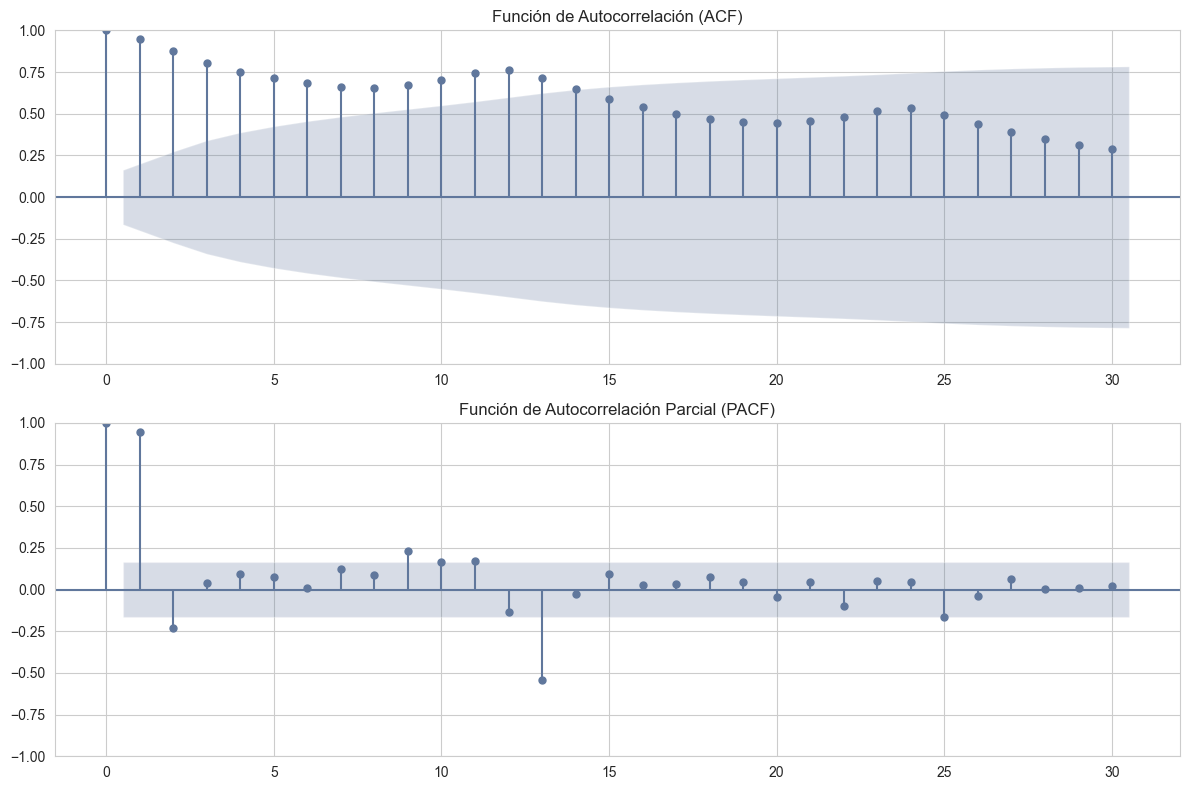

In [35]:
# Gráficos de autocorrelación (ACF) y autocorrelación parcial (PACF)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Crear figura
plt.figure(figsize=(12, 8))

# ACF
plt.subplot(2, 1, 1)
plot_acf(y['passengers'], lags=30, ax=plt.gca())
plt.title("Función de Autocorrelación (ACF)", fontsize=12)

# PACF
plt.subplot(2, 1, 2)
plot_pacf(y['passengers'], lags=30, ax=plt.gca())
plt.title("Función de Autocorrelación Parcial (PACF)", fontsize=12)

plt.tight_layout()
plt.show()

El gráfico muestra las funciones de **autocorrelación (ACF)** y **autocorrelación parcial (PACF)** de la serie de pasajeros aéreos.

* En la parte superior, la **ACF** exhibe una **disminución lenta y gradual**, lo que indica que los valores actuales están fuertemente relacionados con los valores pasados, incluso a grandes retardos.
    
    👉 Esto sugiere que la serie **no es estacionaria**, ya que mantiene “memoria” del pasado.

* En la parte inferior, la **PACF** muestra una **alta correlación en los primeros retardos** y luego una caída brusca.
    
    👉 Este patrón es típico de una serie con un **componente autorregresivo (AR)**, donde los valores cercanos en el tiempo influyen directamente entre sí.





**Prueba de Dickey-Fuller**

En estadística, la **prueba de Dickey-Fuller** se utiliza para determinar si una serie temporal posee una **raíz unitaria**, es decir, si es **no estacionaria**.
La prueba fue desarrollada en 1979 por los estadísticos **David Dickey** y **Wayne Fuller**.

Dependiendo de la versión utilizada, la hipótesis alternativa puede referirse a una serie **estacionaria** o **tendencia-estacionaria**, pero el principio general es el mismo.

Para el caso más común (verificación de estacionariedad), las hipótesis se formulan así:

* **Hipótesis nula ($H_0$):** la serie temporal **no es estacionaria** (tiene raíz unitaria).
* **Hipótesis alternativa ($H_1$):** la serie temporal **es estacionaria**.

Por lo tanto, **rechazar la hipótesis nula** —es decir, obtener un **valor p pequeño**— indica que la serie **puede considerarse estacionaria**.




In [36]:
# Prueba de Dickey-Fuller para verificar estacionariedad
from statsmodels.tsa.stattools import adfuller
import pandas as pd

print("📊 Resultados de la prueba de Dickey-Fuller:")

# Ejecutar el test
resultado = adfuller(y['passengers'], autolag='AIC')

# Organizar resultados principales
df_output = pd.Series(resultado[0:4],
                      index=['Estadístico de prueba', 'Valor p', '# de retardos usados', 'Número de observaciones'])

# Mostrar resultados
print(df_output)

# Interpretación rápida
if resultado[1] <= 0.05:
    print("\n✅ Se rechaza la hipótesis nula: la serie es estacionaria.")
else:
    print("\n❌ No se rechaza la hipótesis nula: la serie no es estacionaria.")


📊 Resultados de la prueba de Dickey-Fuller:
Estadístico de prueba        0.815369
Valor p                      0.991880
# de retardos usados        13.000000
Número de observaciones    130.000000
dtype: float64

❌ No se rechaza la hipótesis nula: la serie no es estacionaria.



**¿Qué se puede hacer si la serie no es estacionaria?**

En nuestro caso de estudio, la serie resultó **no estacionaria**. Sin embargo, existen **transformaciones** que pueden aplicarse para estabilizar su media y varianza, y así cumplir con las condiciones necesarias para el modelado.

Estas transformaciones deben cumplir ciertas propiedades matemáticas (como **inyectividad** y **diferenciabilidad**) para conservar la estructura de los datos.
A continuación, se presentan algunas de las más utilizadas en el análisis de series temporales:

Sea $X_t$ una serie temporal, podemos definir una nueva serie $Y_t$ de la siguiente forma:

* **Diferenciación:**
  $$Y_t = \Delta X_t = X_t - X_{t-1}$$
  Permite eliminar tendencias o patrones de crecimiento, reduciendo la dependencia temporal.

* **Transformación de Box–Cox:**
  $$
  Y_t =
  \begin{cases}
  \dfrac{X_t^{\lambda} - 1}{\lambda}, & \text{si } \lambda \neq 0 \
  \log(X_t), & \text{si } \lambda = 0
  \end{cases}
  $$
  Esta transformación estabiliza la **varianza**, haciendo la serie más homogénea a lo largo del tiempo.



A continuación, utilizaremos **Python** para visualizar cómo se comporta la serie después de aplicar estas transformaciones.




c:\Users\franc\AppData\Local\pypoetry\Cache\virtualenvs\docs-J5aK385Z-py3.10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\franc\AppData\Local\pypoetry\Cache\virtualenvs\docs-J5aK385Z-py3.10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8331 (\N{SUBSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\franc\AppData\Local\pypoetry\Cache\virtualenvs\docs-J5aK385Z-py3.10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


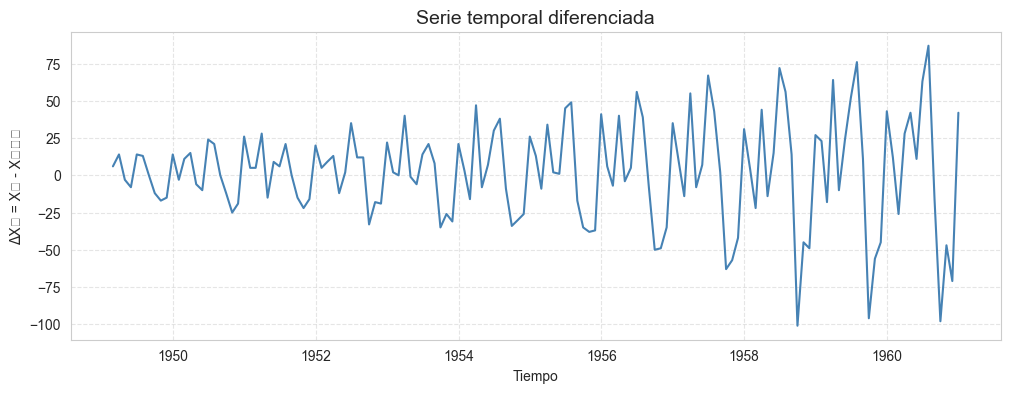

In [37]:
# Diferenciación de la serie temporal

# Aplicar la primera diferencia
Y_diff = y.diff()

# Configuración del gráfico
rcParams['figure.figsize'] = (12, 4)
plt.plot(Y_diff, color='steelblue', linewidth=1.5)
plt.title("Serie temporal diferenciada", fontsize=14)
plt.xlabel("Tiempo")
plt.ylabel("ΔXₜ = Xₜ - Xₜ₋₁")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


En la **primera imagen**, se aplica la **diferenciación**
$$Y_t = X_t - X_{t-1}$$
Esta operación elimina la **tendencia creciente** de la serie original, centrándola alrededor de cero.

El resultado muestra fluctuaciones más estables en el tiempo, lo que indica que **la tendencia ha sido eliminada**, aunque aún puede existir cierta estacionalidad.

c:\Users\franc\AppData\Local\pypoetry\Cache\virtualenvs\docs-J5aK385Z-py3.10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


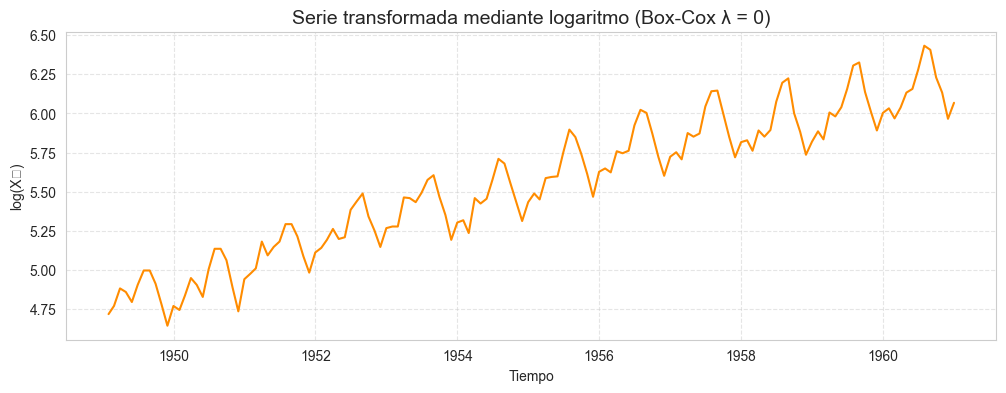

In [38]:
# Función para aplicar transformaciones Box-Cox
def box_transformations(y, lam):
    """
    Aplica la transformación Box-Cox a una serie temporal.
    
    Parámetros:
        y (pd.Series): serie temporal original.
        lam (float): parámetro lambda de la transformación.
        
    Retorna:
        pd.Series transformada o la serie original si λ < 0.
    """
    if lam > 0:
        return y.apply(lambda x: (x**lam - 1) / lam)
    elif lam == 0:
        return np.log(y)
    else:
        print("⚠️ El parámetro λ es negativo. Se devuelve la serie original.")
        return y

# Transformación logarítmica (λ = 0)
Y_log = box_transformations(y, 0)

# Configuración y visualización
rcParams['figure.figsize'] = (12, 4)
plt.plot(Y_log, color='darkorange', linewidth=1.5)
plt.title("Serie transformada mediante logaritmo (Box-Cox λ = 0)", fontsize=14)
plt.xlabel("Tiempo")
plt.ylabel("log(Xₜ)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


En la **segunda imagen**, se aplica la **transformación logarítmica**, equivalente al caso λ = 0 de Box–Cox:
$$Y_t = \log(X_t)$$
Esta transformación **reduce la amplitud de las variaciones** en los valores altos, estabilizando parcialmente la **varianza**.

La serie conserva la tendencia ascendente, pero las oscilaciones se suavizan, lo que la hace más adecuada para el modelado.

c:\Users\franc\AppData\Local\pypoetry\Cache\virtualenvs\docs-J5aK385Z-py3.10\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8348 (\N{LATIN SUBSCRIPT SMALL LETTER T}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


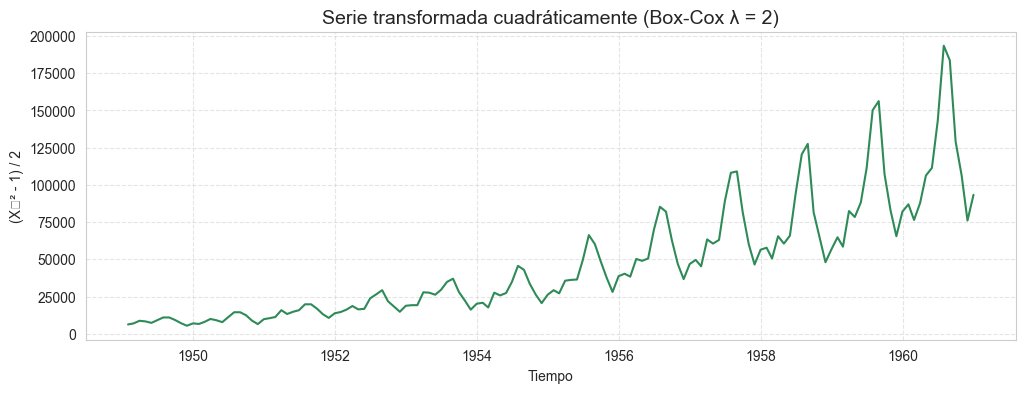

In [39]:
# Transformación cuadrática (Box-Cox con λ = 2)

Y_quad = box_transformations(y, 2)

# Configuración y visualización
rcParams['figure.figsize'] = (12, 4)
plt.plot(Y_quad, color='seagreen', linewidth=1.5)
plt.title("Serie transformada cuadráticamente (Box-Cox λ = 2)", fontsize=14)
plt.xlabel("Tiempo")
plt.ylabel("(Xₜ² - 1) / 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


En la **tercera imagen**, se usa una **transformación cuadrática**:
$$Y_t = \dfrac{X_t^2 - 1}{2}$$
Esta amplifica las diferencias entre valores grandes y pequeños, **acentuando las variaciones**.

A diferencia del logaritmo, esta transformación **aumenta la varianza**, por lo que no es útil para estabilizar la serie, pero sirve para observar cómo cambian las propiedades estadísticas bajo distintos valores de λ.





## Modelos clásicos de pronóstico

En esta sección se presentan los principales **modelos estadísticos clásicos** utilizados para el análisis y pronóstico de series temporales. La idea es avanzar desde los modelos más simples hacia los más generales, entendiendo cómo cada uno extiende al anterior.



### 1. Modelo de Media Móvil $MA(d)$

El modelo $MA(d)$ (Moving Average) describe la variable observada en el tiempo $X_t$ como una combinación lineal del ruido blanco de periodos anteriores:

$$
X_t = \mu + e_t + \theta_1 e_{t-1} + \theta_2 e_{t-2} + \dots + \theta_d e_{t-d}
$$

donde:

* $e_t$ son errores aleatorios con media cero y varianza constante.
* $\theta_i$ son los coeficientes de los rezagos del error.

**Interpretación:** la observación actual depende de los errores pasados en el modelo.

**Aplicación:** útil cuando la serie es estacionaria y muestra correlación corta entre errores sucesivos.


### 2. Modelo Autorregresivo $AR(q)$

El modelo $AR(q)$ (AutoRegressive) expresa el valor actual de la serie como una combinación lineal de sus propios valores pasados:

$$
X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_q X_{t-q} + e_t
$$

donde:

* $\phi_i$ son los coeficientes autorregresivos.
* $e_t$ es un ruido blanco.

**Interpretación:** el valor actual depende directamente de los valores previos de la serie.

**Aplicación:** adecuado para series estacionarias con dependencia temporal fuerte.


### 3. Modelo Autorregresivo de Media Móvil $ARMA(p, q)$

El modelo $ARMA(p, q)$ combina las ideas de los modelos $AR$ y $MA$:

$$
X_t = \phi_1 X_{t-1} + \dots + \phi_p X_{t-p} + e_t + \theta_1 e_{t-1} + \dots + \theta_q e_{t-q}
$$

**Interpretación:** la variable actual depende tanto de sus valores pasados como de los errores pasados.

**Aplicación:** se utiliza en series estacionarias que presentan tanto autocorrelación como dependencia en los errores.


### 4. Modelo Autorregresivo Integrado de Media Móvil $ARIMA(p, d, q)$

El modelo $ARIMA(p, d, q)$ extiende el modelo anterior para manejar series **no estacionarias** mediante la diferenciación.
Si $d$ es el número de diferencias necesarias para volver estacionaria la serie, entonces:

$$
\Delta^d X_t = X_t - X_{t-1} = ARMA(p, q)
$$

**Interpretación:** se diferencia la serie $d$ veces para eliminar tendencias o patrones no estacionarios, y luego se aplica un modelo $ARMA$.

**Aplicación:** series con tendencia pero sin estacionalidad marcada.



### 5. Modelo Estacional Autorregresivo Integrado de Media Móvil $SARIMA(p, d, q) \times (P, D, Q, S)$

El modelo $SARIMA$ incorpora además **comportamientos estacionales** en los datos, permitiendo modelar repeticiones periódicas (por ejemplo, anuales o mensuales).
Su forma general es:

$$
\Phi_P (L^S) (1 - L^S)^D \phi_p (L) (1 - L)^d X_t = \Theta_Q (L^S) \theta_q (L) e_t
$$

donde:

* $(p, d, q)$: parámetros no estacionales.
* $(P, D, Q, S)$: parámetros estacionales.
* $S$: período de la estacionalidad (por ejemplo, $S = 12$ para datos mensuales).

**Interpretación:** combina la parte no estacional del modelo ARIMA con una estructura estacional.

**Aplicación:** series con tendencia y estacionalidad (por ejemplo, número de pasajeros mensuales, ventas por temporada, etc.).



### 6. Otros modelos mencionados

* **ARCH / GARCH:** modelos para series con **volatilidad variable** (fluctuaciones en la varianza), comunes en datos financieros.
* **Modelos de espacio de estados:** generalizan los modelos anteriores para representar sistemas dinámicos complejos, donde las variables observadas dependen de variables latentes (no observadas).



### Jerarquía entre modelos

Existe una relación jerárquica entre todos estos modelos:

$$
MA(d),\ AR(q) \subset ARMA(p, q) \subset ARIMA(p, d, q) \subset SARIMA(p, d, q) \times (P, D, Q, S)
$$

Esto significa que:

* Los modelos $AR$ y $MA$ son casos particulares de $ARMA$.
* $ARMA$ es un caso particular de $ARIMA$ (cuando $d = 0$).
* $ARIMA$ es un caso particular de $SARIMA$ (cuando no hay componente estacional).



### Cuándo usar cada modelo

| Tipo de serie temporal                | Modelo recomendado |
| ------------------------------------- | ------------------ |
| Estacionaria sin estacionalidad       | AR, MA o ARMA      |
| No estacionaria (con tendencia)       | ARIMA              |
| Estacional (con patrones repetitivos) | SARIMA             |
| Volatilidad variable (finanzas)       | ARCH / GARCH       |
| Procesos dinámicos complejos          | Espacio de estados |











### Pronóstico con `statsmodels`

Para realizar el pronóstico utilizaremos los modelos disponibles en `statsmodels`, en particular el modelo
$$SARIMA(p,d,q)(P,D,Q)_S.$$

Como en todo proceso de *machine learning*, debemos dividir los datos en dos conjuntos: **entrenamiento** y **prueba**.
En el caso de las series temporales, esta división se hace según una **fecha objetivo** (*target_date*), sin alterar el orden temporal.

* **$y_{train}$:** todos los datos **hasta** la fecha *target_date*.
* **$y_{test}$:** todos los datos **posteriores** a *target_date*.


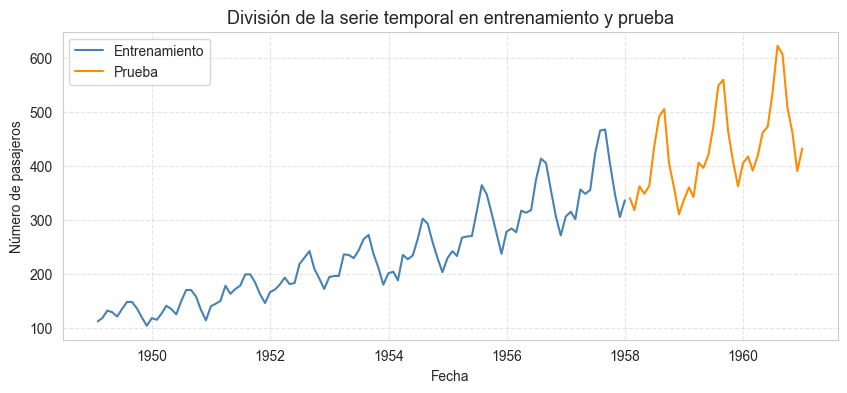

In [40]:
# Definir fecha objetivo para dividir los datos
target_date = '1958-01-01'

# Crear conjuntos de entrenamiento y prueba
y_train = y.loc[y.index < target_date]
y_test  = y.loc[y.index >= target_date]

# Visualizar ambos conjuntos
plt.figure(figsize=(10, 4))
plt.plot(y_train['passengers'], label='Entrenamiento', color='steelblue')
plt.plot(y_test['passengers'], label='Prueba', color='darkorange')
plt.title("División de la serie temporal en entrenamiento y prueba", fontsize=13)
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Una pregunta natural que surge es: **¿por qué no se toman los datos de forma aleatoria?**

La razón es que en una **serie temporal** los datos están ordenados según el **tiempo**, por lo que existe una **dependencia natural** entre observaciones consecutivas.
En cambio, en los problemas clásicos de **regresión**, cada par de datos es generalmente **independiente** y no sigue un orden específico.

Si seleccionáramos los datos de prueba de manera aleatoria, podríamos **romper la secuencia temporal**, alterando la **tendencia** o la **estacionalidad** de la serie, lo que haría que el modelo perdiera sentido.

Veamos un ejemplo sencillo de este caso en Python:

In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def mean_absolute_percentage_error(y_true, y_pred):
    """Calcula el error porcentual absoluto medio (MAPE)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def regression_metrics(df):
    """
    Calcula métricas de evaluación para modelos de series temporales o regresión.

    Parámetros:
        df (pd.DataFrame): DataFrame con columnas ['y', 'yhat'] donde:
            - 'y'    : valores reales
            - 'yhat' : valores predichos

    Retorna:
        pd.DataFrame: tabla con las métricas MAE, MSE, RMSE, MAPE y sMAPE
    """
    y_true = df['y']
    y_pred = df['yhat']

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    smape = 2 * mape / (mape + 100)

    df_result = pd.DataFrame({
        'MAE': [round(mae, 4)],
        'MSE': [round(mse, 4)],
        'RMSE': [round(rmse, 4)],
        'MAPE': [round(mape, 4)],
        'sMAPE': [round(smape, 4)]
    })

    return df_result


In [52]:
# Parámetros SARIMA
param = (1, 0, 0)          # (p, d, q)
seasonal_param = (0, 0, 0, 12)  # (P, D, Q, S) con S=12 (mensual)

# Asegurar que la serie tenga frecuencia temporal explícita (ajusta 'ME' o 'MS' según tu caso)
y_train_ = y_train['passengers'].asfreq('ME')
y_test_  = y_test['passengers'].asfreq('ME')

# Definir y ajustar el modelo
model = SARIMAX(
    y_train_,
    order=param,
    seasonal_order=seasonal_param,
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)

# Rango de predicción usando fechas (respeta el orden temporal)
start_index = y_test_.index.min()
end_index   = y_test_.index.max()

pred_res = model_fit.get_prediction(start=start_index, end=end_index, dynamic=False)
pred_mean = pred_res.predicted_mean
pred_ci   = pred_res.conf_int()  # intervalos de confianza

# Construir DataFrame de evaluación alineado al índice de prueba
df_temp = pd.DataFrame({
    'y':    y_test_,
    'yhat': pred_mean.reindex(y_test_.index)
})

# (Opcional) ver primeras filas
df_temp.head()


,y,yhat
date,,
1958-01-31,340.0,336.756041
1958-02-28,318.0,337.513783
1958-03-31,362.0,338.273230
1958-04-30,348.0,339.034386
1958-05-31,363.0,339.797254


In [53]:
# Resultados de las métricas del modelo
df_metrics = regression_metrics(df_temp)

# Agregar nombre descriptivo del modelo evaluado
df_metrics['Model'] = f"SARIMA_{param[0]}x{param[1]}".replace(' ', '')

# Mostrar resultados
df_metrics

,MAE,MSE,RMSE,MAPE,sMAPE,Model
0,81.8529,11619.4305,107.7935,17.0068,0.2907,SARIMA_1x0


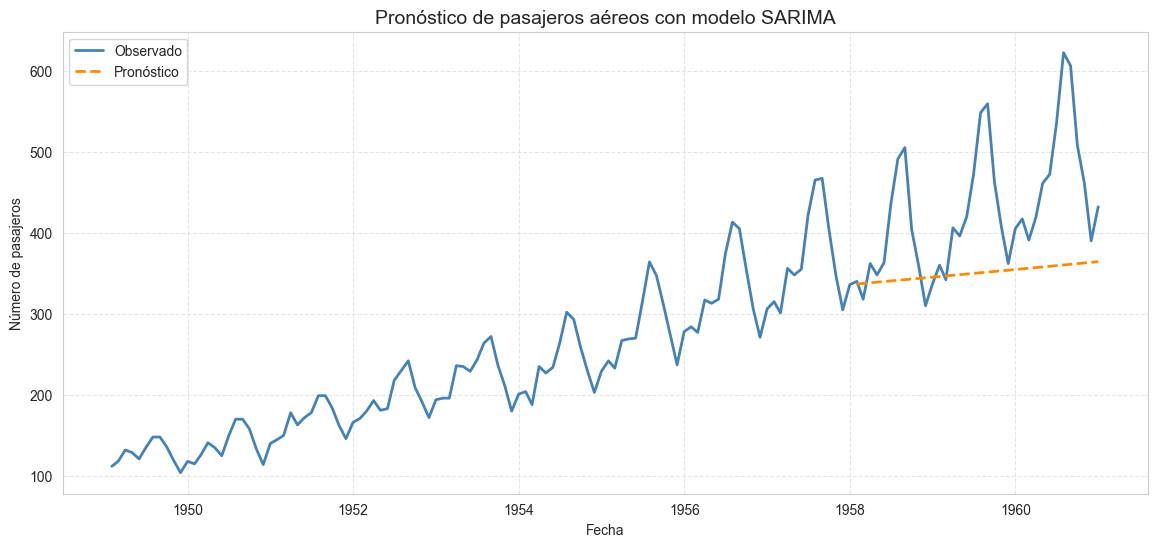

In [54]:
# Gráfico de resultados del modelo SARIMA

plt.figure(figsize=(14, 6))
plt.plot(y['1949':], label='Observado', color='steelblue', linewidth=2)
plt.plot(df_temp['yhat'], label='Pronóstico', color='darkorange', linestyle='--', linewidth=2)

plt.title("Pronóstico de pasajeros aéreos con modelo SARIMA", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

El gráfico muestra el **pronóstico del número de pasajeros** usando un **modelo SARIMA**.

* La **línea azul** representa los valores **observados**.
* La **línea naranja discontinua** muestra el **pronóstico** generado por el modelo.

El modelo capta la **tendencia creciente** de la serie, pero **no reproduce bien la estacionalidad**, por lo que el pronóstico se ve más **suavizado** respecto a los datos reales.





Ahora, ¿cómo podemos hacerlo?
El primer paso es definir una clase llamada `SarimaModels` que **automatice todo el proceso anterior**: ajuste, predicción y evaluación del modelo.
De esta forma, podremos comparar distintos conjuntos de parámetros y **seleccionar aquel que minimice las métricas de error**, como **MAE** (error absoluto medio) y **MAPE** (error porcentual medio).


In [55]:
# creando clase SarimaModels

class SarimaModels:
    def __init__(self,params):

        self.params = params
        
        
    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ','')
    
    @staticmethod
    def test_train_model(y,date):
        mask_ds = y.index < date

        y_train = y[mask_ds]
        y_test = y[~mask_ds]        
        
        return y_train, y_test
    
    def fit_model(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        
        model_fit = model.fit(disp=0)

        return model_fit
    
    def df_testig(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        
        model_fit = model.fit(disp=0)
        
        start_index = y_test.index.min()
        end_index = y_test.index.max()

        preds = model_fit.get_prediction(start=start_index,end=end_index, dynamic=False)
        df_temp = pd.DataFrame(
            {
                'y':y_test['passengers'],
                'yhat': preds.predicted_mean
            }
        )
        
        return df_temp
    
    def metrics(self,y,date):
        df_temp = self.df_testig(y,date)
        df_metrics = regression_metrics(df_temp)
        df_metrics['model'] = self.name_model
        
        return df_metrics

In [56]:
# definir parametros 

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

params = list(itertools.product(pdq,seasonal_pdq))
target_date = '1958-01-01'

In [57]:
# iterar para los distintos escenarios

frames = []
for param in params:
    try:
        sarima_model = SarimaModels(param)
        df_metrics = sarima_model.metrics(y,target_date)
        frames.append(df_metrics)
    except:
        pass

In [60]:
# juntar resultados de las métricas y comparar
df_metrics_result = pd.concat(frames)
df_metrics_result.sort_values(['MAE','MAPE'])

,MAE,MSE,RMSE,MAPE,sMAPE,model
0,16.4272,406.5114,20.1621,4.1002,0.0788,"SARIMA_(0,1,0)X(1,0,0,12)"
0,17.7173,469.8340,21.6757,4.2001,0.0806,"SARIMA_(0,1,1)X(1,1,1,12)"
0,17.7204,480.9764,21.9312,4.1431,0.0796,"SARIMA_(1,1,0)X(1,1,1,12)"
0,17.8053,501.0603,22.3844,4.1164,0.0791,"SARIMA_(1,1,1)X(0,1,0,12)"
0,17.8056,505.4167,22.4815,4.1061,0.0789,"SARIMA_(0,1,0)X(0,1,0,12)"
...,...,...,...,...,...,...
0,94.9444,14674.5556,121.1386,19.8867,0.3318,"SARIMA_(0,1,0)X(0,0,0,12)"
0,360.7115,150709.0664,388.2127,82.0329,0.9013,"SARIMA_(0,0,1)X(0,0,1,12)"
0,366.5303,153175.7993,391.3768,83.7030,0.9113,"SARIMA_(0,0,0)X(0,0,1,12)"
0,422.9626,187068.9748,432.5147,98.3713,0.9918,"SARIMA_(0,0,1)X(0,0,0,12)"


En este caso, el mejor desempeño lo obtiene el modelo **$SARIMA(0,1,0)\times(1,0,0,12)$**. Veamos en el siguiente gráfico cómo se ajusta este modelo a los datos observados.

In [ ]:
# Ajustar mejor modelo (manteniendo tu interfaz)

param = [(0,1,0),(1,0,0,12)]
sarima_model =  SarimaModels(param)
model_fit = sarima_model.fit_model(y,target_date)
best_model = sarima_model.df_testig(y,target_date)
best_model.head()

,y,yhat
1958-01-31,340.0,345.765806
1958-02-28,318.0,330.574552
1958-03-31,362.0,390.254476
1958-04-30,348.0,381.573760
1958-05-31,363.0,389.169386


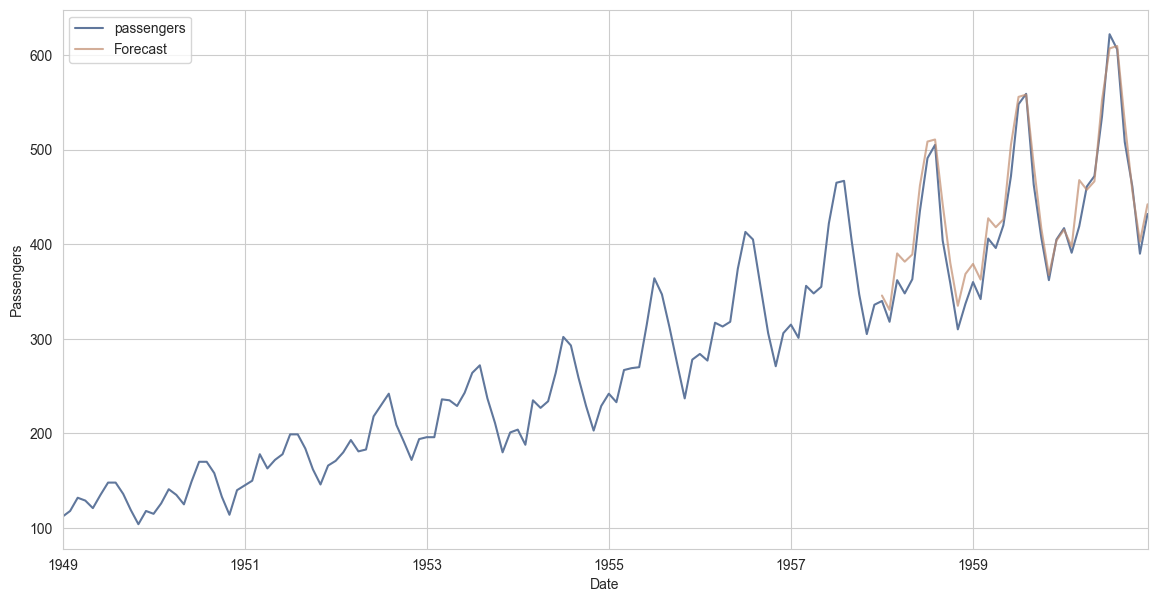

In [66]:
# Graficar el mejor modelo

# Se extraen las predicciones del modelo ajustado
preds = best_model['yhat']

# Se grafica la serie original desde 1949 en adelante
ax = y['1949':].plot(label='observed')

# Se superponen las predicciones sobre la misma figura
preds.plot(ax=ax, label='Forecast', alpha=.7, figsize=(14, 7))

# Se agregan etiquetas a los ejes
ax.set_xlabel('Date')
ax.set_ylabel('Passengers')

# Se muestra la leyenda y el gráfico final
plt.legend()
plt.show()


El gráfico muestra la comparación entre los **valores reales** (línea azul) y el **pronóstico del modelo SARIMA** (línea naranja).
Se observa que el modelo **reproduce bien la tendencia y estacionalidad** de los pasajeros, aunque con **ligeras diferencias** en algunos picos.




Finalmente, analizamos los **errores del modelo** utilizando la función **`plot_diagnostics`**, que genera cuatro gráficos complementarios para evaluar el comportamiento de los residuales desde distintas perspectivas.


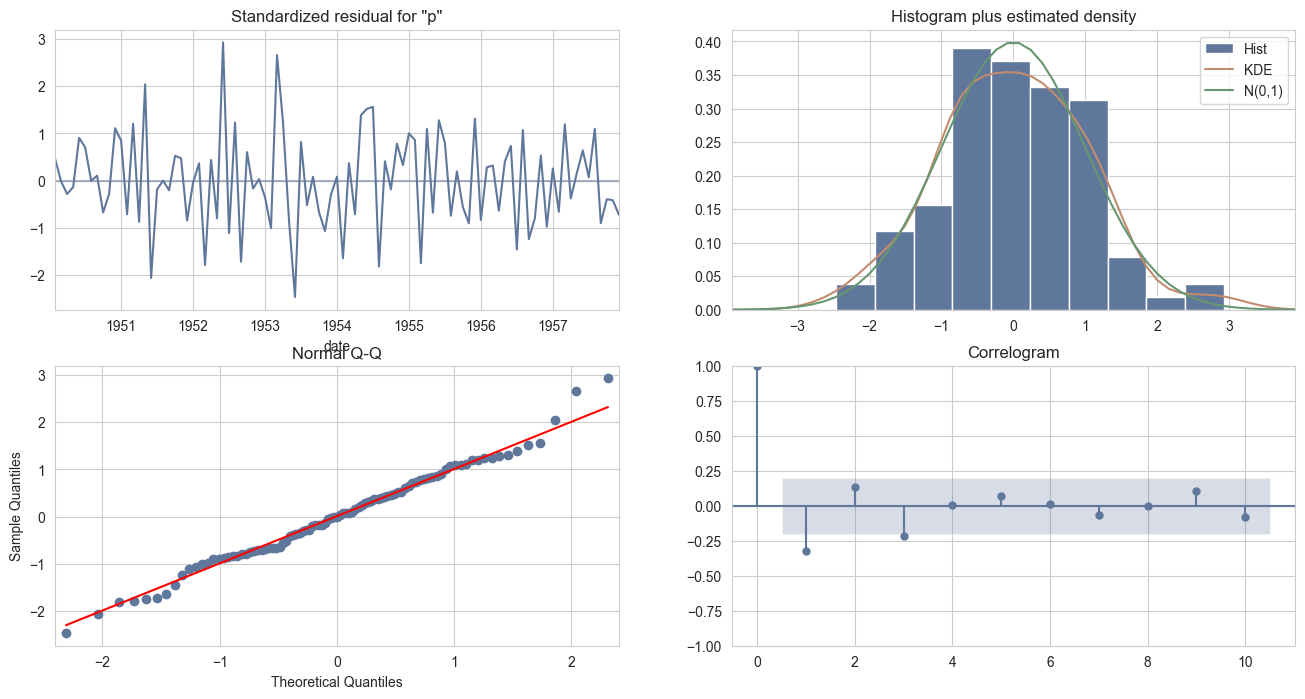

In [67]:
# Evaluar los errores del modelo
# La función plot_diagnostics muestra cuatro gráficos que permiten analizar los residuales
model_fit.plot_diagnostics(figsize=(16, 8))
plt.show()

Estos cuatro gráficos son el resultado de la función `plot_diagnostics()` de `statsmodels` y permiten evaluar si los **residuales** del modelo SARIMA cumplen los supuestos estadísticos.

**1. Residual estandarizado (arriba izquierda):**
Muestra los errores a lo largo del tiempo. Lo ideal es que fluctúen alrededor de cero sin mostrar patrones, lo que indica que el modelo capturó bien la estructura temporal.

**2. Histograma y densidad (arriba derecha):**
Compara la distribución de los residuales con una normal estándar. Si ambas curvas (KDE y N(0,1)) se superponen bien, los errores pueden considerarse aproximadamente normales.

**3. Gráfico Q-Q (abajo izquierda):**
Contrasta los cuantiles teóricos de una distribución normal con los cuantiles observados. Los puntos cercanos a la línea roja indican que los residuales siguen una distribución normal.

**4. Correlograma (abajo derecha):**
Muestra la autocorrelación de los residuales. La ausencia de barras significativas fuera del intervalo de confianza (zona azul) indica que no queda estructura temporal por modelar.



## Prophet

[**Prophet**](https://facebook.github.io/prophet/) es un modelo desarrollado por el equipo **Core Data Science de Facebook** para el **pronóstico de series temporales**. Se basa en un enfoque **aditivo**, donde la serie se descompone en componentes de **tendencia**, **estacionalidad** (anual, semanal y diaria) y **efectos especiales** como feriados o eventos.

Este método destaca por su capacidad para:

* Adaptarse a **tendencias no lineales**.
* Manejar **datos faltantes** y **cambios de tendencia**.
* Ser **robusto frente a valores atípicos**.
* Ofrecer resultados confiables en series con **fuerte estacionalidad** y suficientes datos históricos.

Prophet es un proyecto **de código abierto**, disponible tanto en **CRAN (R)** como en **PyPI (Python)**.

> **Nota:** Para una descripción técnica detallada del modelo, consulte el [artículo original](https://peerj.com/preprints/3190/).


In [ ]:
from prophet import Prophet

# rename 
y_train_prophet = y_train.reset_index()
y_train_prophet.columns = ["ds","y"]

y_test_prophet = y_test.reset_index()
y_test_prophet.columns = ["ds","y"]

# model
m = Prophet()
m.fit(y_train_prophet)

# forecast
future = m.make_future_dataframe(periods=365*4)
forecast = m.predict(future)[['ds', 'yhat']]
forecast.tail()

21:30:16 - cmdstanpy - INFO - Chain [1] start processing
21:30:16 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
1563,1961-12-26,537.016442
1564,1961-12-27,536.103087
1565,1961-12-28,534.348944
1566,1961-12-29,531.776196
1567,1961-12-30,528.429895


In [72]:
# metrics
result = y_test_prophet.merge(forecast,on = 'ds',how='inner')
regression_metrics(result)

,MAE,MSE,RMSE,MAPE,sMAPE
0,39.9165,2013.1444,44.8681,9.8461,0.1793


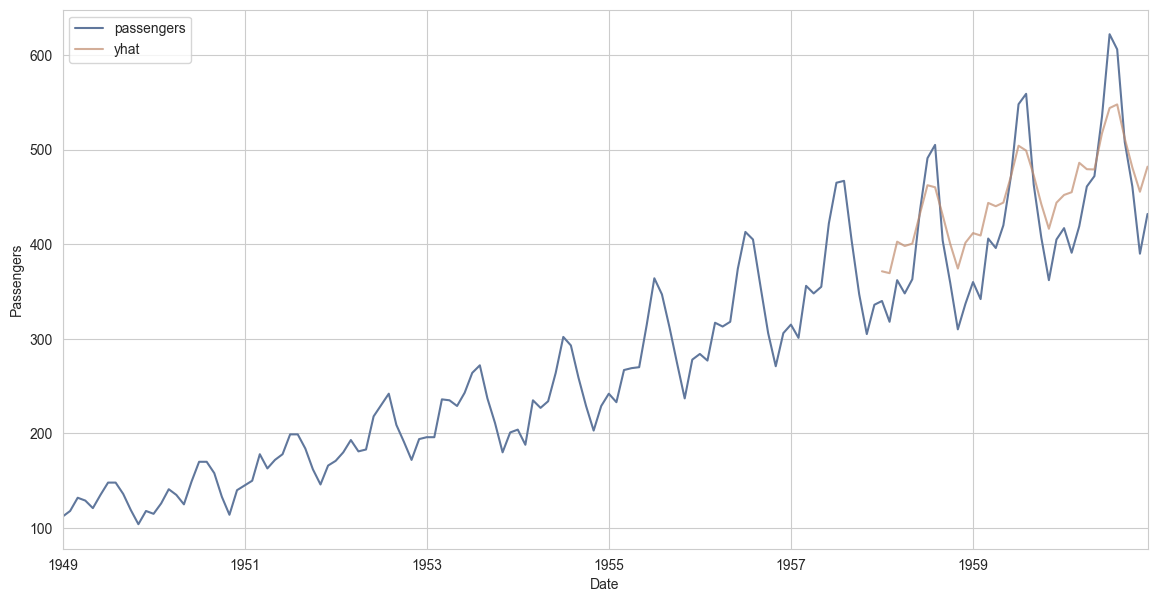

In [73]:
# Graficar las predicciones del modelo Prophet frente a los valores reales

# Se preparan las predicciones con el índice de fechas
preds = result[['ds', 'yhat']].set_index("ds")

# Serie observada y pronosticada
ax = y['1949':].plot(label='Observed', figsize=(14, 7))
preds.plot(ax=ax, label='Forecast', alpha=0.7)

# Detalles del gráfico
ax.set_xlabel('Date')
ax.set_ylabel('Passengers')
plt.legend()
plt.show()


El gráfico muestra el **ajuste del modelo Prophet** sobre la serie de pasajeros aéreos.

* La **línea azul** representa los valores **observados** (reales) de pasajeros a lo largo del tiempo.
* La **línea naranja** corresponde a las **predicciones del modelo** (`yhat`).

Se aprecia que Prophet **captura correctamente la tendencia creciente** y la **estacionalidad anual** de la serie, reproduciendo el patrón general de aumentos y descensos a lo largo de los años.
Sin embargo, en algunos puntos se observan **diferencias en los picos máximos y mínimos**, lo que indica pequeñas desviaciones del modelo frente a las observaciones reales.



## Conclusión

Este capítulo presentó una **introducción práctica y accesible al análisis de series temporales**, abordando desde la exploración inicial de los datos hasta la aplicación de modelos clásicos como **SARIMA** y modernos como **Prophet**.

Se mostró cómo evaluar la **estacionariedad**, ajustar modelos, interpretar sus **métricas de error** y analizar los **residuales** para validar la calidad del pronóstico. Aunque existen muchas otras metodologías y variantes más complejas, los modelos revisados permiten comprender los principios fundamentales del pronóstico y aplicar soluciones efectivas en una amplia gama de escenarios reales.




## Referencias


1. [A comprehensive beginner’s guide to create a Time Series Forecast (with Codes in Python and R)](https://www.analyticsvidhya.com/blog/2016/02/time-series-forecasting-codes-python/)
2. [A Gentle Introduction to SARIMA for Time Series Forecasting in Python](https://machinelearningmastery.com/sarima-for-time-series-forecasting-in-python/)
3. [An Introductory Study on Time Series Modeling and Forecasting ](https://arxiv.org/pdf/1302.6613.pdf)